# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1') #загрузка таблицы
df.sample(4) #вывод 4 случайных строк

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
10827,16936,61888,Probs in Chicago or Edinburgh,21-03-2020,Spotted at my local supermarket...as opposed t...,Extremely Negative
2622,6969,51921,Deutschland,18-03-2020,A supermarket in Denmark got tired of people h...,Negative
22287,31026,75978,"Indianapolis, IN",03-04-2020,economist says are prepared for despite uncert...,Positive
3477,8020,52972,NaN,18-03-2020,"Covid 19 scare in Camp Hill, Pa. leaves Giant ...",Negative


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df["Sentiment"] = ((df["Sentiment"] == "Positive") | (df["Sentiment"] == "Extremely Positive")).astype(int) #перекодировка целевой переменной

Сбалансированы ли классы?

In [4]:
df["Sentiment"].value_counts() #вывод частоты уникальных значений в столбце "Sentiment"

Sentiment
1    18046
0    15398
Name: count, dtype: int64

**Ответ:** классы не сбалансированы, твиттов с положительной окраской немного больше, чем с отрицательной.

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [5]:
df.isnull().sum() #вывод количества пропусков в каждом столбце

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [6]:
df["Location"] = df["Location"].fillna("Unknown") #замена пропусков в столбце "Location"
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,Unknown,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,Unknown,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0) #разделение данных на обучающие и тестовые

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [8]:
train["OriginalTweet"]

25621    Why we still want to buy so much stuff during ...
30135    With driving even more usage a strong strategy...
28899    @Canon_India I am very happy.. Great job by @C...
5989     The U.S national debt will likely exceed $30 T...
4367     Finally got to the grocery store. Honestly, wh...
                               ...                        
20757    Football is in ruins right now.When it will re...
32103    Hand sanitizer made here on the Skellig Coast!...
30403    An initiative  taken by our  @GOLDENINITIATI1 ...
21243    Vile premiership players demanding full wages ...
2732     Just wondering why we arenÃÂt screening at t...
Name: OriginalTweet, Length: 23410, dtype: object

In [9]:
#токенизация
texts = train["OriginalTweet"].tolist() #создание списка твитов из обучающих данных
tokens = [w.lower() for t in texts for w in t.split()] #осуществление токенизации по пробелам
tokens

['why',
 'we',
 'still',
 'want',
 'to',
 'buy',
 'so',
 'much',
 'stuff',
 'during',
 'quarantine',
 'https://t.co/1m881cwfuv',
 '#shopping',
 '#covid_19',
 '#online',
 'with',
 'driving',
 'even',
 'more',
 'usage',
 'a',
 'strong',
 'strategy',
 'is',
 'critical',
 'now',
 'more',
 'then',
 'ever',
 'luckily',
 'and',
 'april',
 '16',
 'webinar',
 'will',
 'dive',
 'into',
 'growing',
 'app',
 'awareness',
 'and',
 'targeting',
 'high',
 'lifetime',
 'value',
 'users',
 '@canon_india',
 'i',
 'am',
 'very',
 'happy..',
 'great',
 'job',
 'by',
 '@canon_india',
 '#canonforcommunity',
 'https://t.co/z0intks34x',
 'the',
 'u.s',
 'national',
 'debt',
 'will',
 'likely',
 'exceed',
 '$30',
 'trillion',
 'after',
 'the',
 'unprecedented',
 'borrowing',
 'by',
 'the',
 'trump',
 'administration',
 'and',
 'mnuchinã\x82â\x92s',
 'treasury',
 'during',
 'the',
 '#coronavirus',
 'crisis.',
 'the',
 'federal',
 'reserve',
 'could',
 'be',
 'doing',
 'much',
 'more',
 'to',
 'cushion',
 'the',

In [10]:
#словарь
dictionary = {}
for token in tokens:
    dictionary[token] = dictionary.get(token, 0) + 1
print(dictionary)

{'why': 654, 'we': 3787, 'still': 763, 'want': 487, 'to': 23373, 'buy': 748, 'so': 1837, 'much': 482, 'stuff': 106, 'during': 1908, 'quarantine': 154, 'https://t.co/1m881cwfuv': 1, '#shopping': 121, '#covid_19': 1660, '#online': 40, 'with': 4063, 'driving': 77, 'even': 682, 'more': 2008, 'usage': 22, 'a': 11737, 'strong': 93, 'strategy': 33, 'is': 7383, 'critical': 156, 'now': 1349, 'then': 435, 'ever': 179, 'luckily': 8, 'and': 14684, 'april': 163, '16': 36, 'webinar': 65, 'will': 2726, 'dive': 10, 'into': 666, 'growing': 84, 'app': 52, 'awareness': 32, 'targeting': 9, 'high': 408, 'lifetime': 4, 'value': 79, 'users': 19, '@canon_india': 16, 'i': 5340, 'am': 424, 'very': 418, 'happy..': 1, 'great': 409, 'job': 242, 'by': 2236, '#canonforcommunity': 5, 'https://t.co/z0intks34x': 1, 'the': 26815, 'u.s': 8, 'national': 123, 'debt': 68, 'likely': 170, 'exceed': 14, '$30': 7, 'trillion': 21, 'after': 886, 'unprecedented': 89, 'borrowing': 5, 'trump': 228, 'administration': 38, 'mnuchinã\x8

Какой размер словаря получился?

In [11]:
dict_df = pd.DataFrame.from_dict(dictionary, orient='index').reset_index() #преобразование словаря в датафрейм (ключи - строки), добавление колонки с порядковыми индексами
dict_df.columns = ['Token', 'Frequency'] #даем названия колонкам
dict_df.shape[0] #размер словаря

79755

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [12]:
dict_df.sort_values(by = "Frequency", ascending = False).head(10)

,Token,Frequency
54,the,26815
4,to,23373
29,and,14684
129,of,13012
20,a,11737
141,in,11198
204,for,8566
69,#coronavirus,8223
23,is,7383
89,are,7050


**Ответ:** наиболее часто употребляемыми токенами оказались артикли (the, a) и предлоги/союзы (to, and, of, in, for), которые встречаются практически в каждом предложении вне зависимости от тональности. Такие слова не несут никакого смыслового значения и зачастую называются "шумом" или "мусором". В 10-ку наиболее часто встречающихся токенов также попали хэштэг "#coronavirus" и обе формы глагола "to be" в настоящем времени. Если ситуация с глаголом "to be" аналогична ситуации с артиклями и предлогами (глагол "to be" - это чаще всего вспомогательный глагол, который встречается в английском языке очень часто), то попадание сюда хэштэга - это уже более интересно. Т.к. данные содержат твиты, опубликованные в период коронавируса, неудивительно, что этот хэштэг оказался наиболее популярным: в период пандемии все сидели дома, общались в социальных сетях, коронавирус был всемирной темой для обсуждения, а также способом призывать других людей оставаться дома, носить средства индивидуальной защиты, а также способом распространять новости.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [13]:
import nltk

nltk.download("stopwords", quiet=True)

True

In [14]:
from nltk.corpus import stopwords

stop_w = stopwords.words("english")

dict_df_without_stop_w = dict_df.drop(dict_df[dict_df["Token"].isin(stop_w)].index)
dict_df_without_stop_w.sort_values(by = "Frequency", ascending = False).head(10)

,Token,Frequency
69,#coronavirus,8223
432,prices,3891
99,food,3820
85,grocery,3469
202,supermarket,3288
91,people,3175
144,covid-19,3173
183,store,3155
198,#covid19,2471
636,&amp;,2314


**Ответ:**  большая часть токенов из нового топа - это слова, связанные с магазинами и ценами, что может быть вызвано тем, что именно повышение цен, дефицит товаров и т.п. были наиболее острыми темами для обсуждения в период пандемии. К хэштэгу "#coronavirus" добавляется его эквивалент "#covid-19".

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [15]:
dict_df_without_stop_w.sort_values(by = "Frequency", ascending = True).head(20)

,Token,Frequency
39966,intensified;,1
52912,@fox5ny,1
52911,@chasingnews,1
52910,https://t.co/h0olgczshoãâ,1
52909,covid-19ãâ..,1
52908,ãâprice,1
52907,affairs:,1
52913,@my9nj,1
52906,"""isolation""",1
52903,portrays,1


**Ответ:** приведенные выше токены непопулярны, потому что в большинстве случаев это либо ссылки (уникальные для каждого сайта и неповторяющиеся), либо слова со знаками препинания, которые в идеале надо было убрать.

Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [16]:
#токенизация
from nltk.tokenize import TweetTokenizer

tw = TweetTokenizer()

tw_tokens = [w for t in texts for w in tw.tokenize(t)]
tw_tokens

['Why',
 'we',
 'still',
 'want',
 'to',
 'buy',
 'so',
 'much',
 'stuff',
 'during',
 'quarantine',
 'https://t.co/1m881CwFUv',
 '#shopping',
 '#Covid_19',
 '#Online',
 'With',
 'driving',
 'even',
 'more',
 'usage',
 'a',
 'strong',
 'strategy',
 'is',
 'critical',
 'now',
 'more',
 'then',
 'ever',
 'Luckily',
 'and',
 'April',
 '16',
 'webinar',
 'will',
 'dive',
 'into',
 'growing',
 'app',
 'awareness',
 'and',
 'targeting',
 'high',
 'lifetime',
 'value',
 'users',
 '@Canon_India',
 'I',
 'am',
 'very',
 'happy',
 '..',
 'Great',
 'job',
 'by',
 '@Canon_India',
 '#CanonForCommunity',
 'https://t.co/Z0intkS34x',
 'The',
 'U',
 '.',
 'S',
 'national',
 'debt',
 'will',
 'likely',
 'exceed',
 '$',
 '30',
 'Trillion',
 'after',
 'the',
 'unprecedented',
 'borrowing',
 'by',
 'the',
 'Trump',
 'administration',
 'and',
 'MnuchinÃ',
 '\x82',
 'Â',
 '\x92',
 's',
 'Treasury',
 'during',
 'the',
 '#coronavirus',
 'crisis',
 '.',
 'The',
 'Federal',
 'Reserve',
 'could',
 'be',
 'doing',

In [17]:
#словарь
dict_tw = {}
for token in tw_tokens:
    dict_tw[token] = dict_tw.get(token, 0) + 1
    
dict_tw_df = pd.DataFrame.from_dict(dict_tw, orient='index').reset_index()
dict_tw_df.columns = ['Token', 'Frequency']

dict_tw_df.sort_values(by = "Frequency", ascending = False).head(10)

,Token,Frequency
67,the,24337
57,.,24118
4,to,22933
97,",",17571
29,and,14354
144,of,12904
20,a,11045
156,in,10573
106,?,9524
225,for,8228


**Ответ:** наиболее часто встречающимися токенами опять оказались "стоп-слова", но к ним добавились еще и знаки препинания (точка, запятая и знак вопроса), которые ранее просто приклеивались к словам, т.к. токенизация осуществлялась по пробелам.

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [18]:
from string import punctuation

noise = stop_w + list(punctuation)
dict_tw_df_without_noise = dict_tw_df.drop(dict_tw_df[dict_tw_df["Token"].isin(noise)].index)
dict_tw_df_without_noise.sort_values(by = "Frequency", ascending = False).head(10)

,Token,Frequency
74,Â,7415
73,,7311
161,19,7167
78,#coronavirus,7143
45,I,5235
75,,4372
452,prices,4281
159,COVID,4218
112,food,3795
95,store,3691


**Ответ:** да, теперь в топе встречаются отдельные символы (строки 74, 73, 45, 75) и цифра "19", вероятно, отделенная от хэштэга "#covid-19". Могу предположить, что прямоугольники - это какие-то эмодзи.

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [19]:
condition = (dict_tw_df_without_noise["Token"].apply(lambda x: len(x) == 1 and ord(x) >= 128))

dict_tw_df_new = dict_tw_df_without_noise.drop(dict_tw_df_without_noise[condition].index)
dict_tw_df_new.sort_values(by = "Frequency", ascending = False).head(10) 

,Token,Frequency
161,19,7167
78,#coronavirus,7143
45,I,5235
452,prices,4281
159,COVID,4218
112,food,3795
95,store,3691
223,supermarket,3373
94,grocery,3083
101,people,3047


In [20]:
dict_tw_df_new.sort_values(by = "Frequency", ascending = True).head(20)

,Token,Frequency
68227,https://t.co/7j2Y3rSld9,1
51365,https://t.co/6qz2aIe3F5,1
51364,13.3,1
31660,https://t.co/9jMkG6XlFe,1
31661,https://t.co/j0wLcypsus,1
51363,https://t.co/Yr9qXAfkTe,1
51362,#HygienicFood,1
51361,#HygienicWashrooms,1
31665,rool,1
31657,https://t.co/9PFOGK88DP,1


**Ответ:** топ-10 самых популярных токенов не сильно изменился, к уже встречавшимся словам добавились число 19, "COVID" и "I" (на мой взгляд, странно, что это не "стоп-слово"), а топ-20 самых непопулярных токенов теперь не содержат слова с приклееными к ним знаками препинания, а являются непопулярными хэштэгами и ссылками.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [21]:
hashtags_condition = dict_tw_df_new["Token"].apply(lambda x: x[0] == "#")
hashtags_df = dict_tw_df_new[hashtags_condition] #датафрейм с хэштегами
hashtags_df.sort_values(by = "Frequency", ascending = False).head(10) 

,Token,Frequency
78,#coronavirus,7143
218,#COVID19,1844
13,#Covid_19,1463
219,#Coronavirus,1281
926,#COVID2019,927
148,#toiletpaper,657
1420,#covid19,568
1068,#COVID,542
194,#CoronaCrisis,426
2659,#CoronaVirus,351


**Ответ:** практически все хэштэги - это различные вариации слова "коронавирус".

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [22]:
links_condition = dict_tw_df_new["Token"].apply(lambda x: x.startswith("https://t.co"))
links_df = dict_tw_df_new[links_condition]
links_df.sort_values(by = "Frequency", ascending = False).head(10) 

,Token,Frequency
18862,https://t.co/oXA7SWtoNd,5
2598,https://t.co/gP3EusapL8,4
10476,https://t.co/kuwIpF1KQW,3
33576,https://t.co/bYlqXrjmNT,3
36409,https://t.co/WuiEEfSNOj,3
11936,https://t.co/zjNRx6dKKN,3
10290,https://t.co/WrLHYzIzAA,3
28042,https://t.co/G63RP042HO,3
16151,https://t.co/e2ZNXajPre,3
26644,https://t.co/CATKegAyOY,3


**Ответ:** популярность ссылок совсем не сравнима с популярностью хэштэгов: самый популярный хэштэг "#coronavirus" встречается примерно в 1429 раз чаще, чем самая популярная ссылка, а если учесть тот факт, что остальные популярные хэштэги тоже про коронавирус, то этот разрыв еще больше.

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [23]:
from nltk.tokenize import TweetTokenizer

import nltk
from nltk.corpus import stopwords

from string import punctuation

tw = TweetTokenizer()

stop_w = stopwords.words("english")
noise = stop_w + list(punctuation)

def custom_tokenizer(text):
    text_low = text.lower() #приведение текста в нижний регистр

    tw_tokens = tw.tokenize(text_low) #применение токенайзера

    tokens = []

    for w in tw_tokens:
        if w in noise:
            continue
        if len(w) == 1 and ord(w) >= 128:
            continue
        if w.startswith("https://t.co"):
            continue
        tokens.append(w)
              
    return tokens

In [24]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

#texts = train["OriginalTweet"].tolist() 
#список строк (твитов)

cv = CountVectorizer(tokenizer=custom_tokenizer, lowercase=False) 
X = cv.fit_transform(texts)

print(len(cv.vocabulary_))

C:\Anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


**Ответ:** размер словаря уменьшился почти в 2 раза. В исходном словаре было 79755 токенов, в новом - 45290.

Посмотрим на какой-нибудь конкретный твитт:

In [26]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 0)

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [27]:
vec = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out()).iloc[ind].to_dict()
vec_upd = {k: v for k, v in vec.items() if v != 0}
vec_upd

{'#coronavirusoutbreak': 1,
 '#covid2019': 1,
 '@skynews': 1,
 'brainless': 1,
 'ffs': 1,
 'food': 1,
 'france': 1,
 'lets': 1,
 'nice': 1,
 'one': 1,
 'panic': 1,
 'ppl': 1,
 'queueing': 1,
 'show': 1}

In [28]:
max_freq = max(vec_upd.values())
min_freq = min(vec_upd.values())
tokens_with_max_freq = [k for k, v in vec_upd.items() if v == max_freq]
tokens_with_min_freq = [k for k, v in vec_upd.items() if v == min_freq]
print(tokens_with_max_freq)
print(tokens_with_min_freq)

['#coronavirusoutbreak', '#covid2019', '@skynews', 'brainless', 'ffs', 'food', 'france', 'lets', 'nice', 'one', 'panic', 'ppl', 'queueing', 'show']
['#coronavirusoutbreak', '#covid2019', '@skynews', 'brainless', 'ffs', 'food', 'france', 'lets', 'nice', 'one', 'panic', 'ppl', 'queueing', 'show']


**Ответ:** самый важный и самый неважный токены определились плохо, т.к. каждое из слов встречалось по 1 разу.

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=False)
X_tfidf = tfidf_vec.fit_transform(texts)

vec_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out()).iloc[ind].to_dict()
vec_tfidf_upd = {k: v for k, v in vec_tfidf.items() if v != 0}
max_tfidf = max(vec_tfidf_upd.values())
min_tfidf = min(vec_tfidf_upd.values())
tokens_with_max_tfidf = [k for k, v in vec_tfidf_upd.items() if v == max_tfidf]
tokens_with_min_tfidf = [k for k, v in vec_tfidf_upd.items() if v == min_tfidf]
print(tokens_with_max_tfidf)
print(tokens_with_min_tfidf)

C:\Anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


['brainless']
['food']


**Ответ:** теперь самый важный и самый неважный токены определились хорошо (самый важный токен - "brainless", а самый неважный - "food"), т.к. TfidfVectorizer учитывает не только частоту встречаемости слова в 1 конкретном тексте, но и то, как часто оно встречается в остальных текстах выборки.

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [30]:
train[train['OriginalTweet'].apply(lambda x: 'incredible' in x) & (train['Sentiment'] == 1)]

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
3505,8053,53005,Canada,18-03-2020,A lot of well deserved appreciation toward our...,1
30265,40981,85933,"New York, NY",10-04-2020,Truly incredible consumer behavior graphs in t...,1
944,4938,49890,"Capital Region, NY, USA",17-03-2020,We encourage you to find safe and creative way...,1
23999,33136,78088,Atlanta area,05-04-2020,who through incredible selfishness is keeping ...,1
20783,29152,74104,"Regina, Saskatchewan",31-03-2020,Rawlco Radio has been an incredible partner of...,1
16034,23306,68258,"Finland, LatAm",24-03-2020,"People need easy, safe and immediate access se...",1
21120,29558,74510,Unknown,01-04-2020,Sending a virtual thanks round of applause to ...,1
17228,24764,69716,Brazil,25-03-2020,Hello has hit some hard times due to COVID 19 ...,1
19556,27611,72563,Chicago | Seat 21A on a plane,26-03-2020,This is an incredible tale of a forward lookin...,1
29859,40462,85414,Lowell USA,09-04-2020,They reduced the number of people allowed in t...,1


In [31]:
tweet = train.loc[21120]["OriginalTweet"]
tweet

'Sending a virtual thanks round of applause to all the NHS Medical Staff Ambulance Services support workers supermarket workers and frontline staff that are doing such an amazing job You are all incredible  '

In [32]:
position = train.index.get_loc(21120)
position

6386

In [33]:
vec_tfidf_new = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out()).iloc[position].to_dict()
vec_tfidf_new_upd = {k: v for k, v in vec_tfidf_new.items() if v != 0}
max_tfidf_new = max(vec_tfidf_new_upd.values())
min_tfidf_new = min(vec_tfidf_new_upd.values())
tokens_with_max_tfidf_new = [k for k, v in vec_tfidf_new_upd.items() if v == max_tfidf_new]
tokens_with_min_tfidf_new = [k for k, v in vec_tfidf_new_upd.items() if v == min_tfidf_new]
print(tokens_with_max_tfidf_new)
print(tokens_with_min_tfidf_new)

['applause']
['supermarket']


**Ответ:** в данном случае TfidfVectorizer выделил слово "applause" (аплодисменты) как самый важный токен в данном твите и слово "supermarket" как самый неважный. Получается, что слово "аплодисменты" встречается в остальных текстах довольно редко, поэтому в этом конкретном твите оно обладает высокой важностью по сравнению с остальными. Со словом "супермаркет" ситуация обратная - оно обладает наименьшей важностью за счет того, что является одним из самых популярных в выборке (см. задание 2). На мой взгляд, в данном случае TfidfVectorizer сработал хорошо, т.к. слово "аплодисменты" явно имеет положительную окраску и врядли будет интерпретироваться иначе.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [34]:
#создание матриц с признаками уже было совершено в предыдущем задании

#texts = train["OriginalTweet"].tolist() 
#обучающий список твитов

texts_test = test["OriginalTweet"].tolist()
#тестовый список твитов

#cv = CountVectorizer(tokenizer=custom_tokenizer, lowercase=False) 
#X = cv.fit_transform(texts)
X_test = cv.transform(texts_test)

#tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer, lowercase=False)
#X_tfidf = tfidf_vec.fit_transform(texts)
X_tfidf_test = tfidf_vec.transform(texts_test)

y_train = train["Sentiment"]
y_test = test["Sentiment"]

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#обучение логистической регресии на векторах из CountVectorizer
clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X, y_train)
pred = clf.predict(X_test)
print(accuracy_score(y_test, pred))

0.8670520231213873


In [36]:
#обучение логистической регресии на векторах из TfidfVectorizer
clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_tfidf, y_train)
pred = clf.predict(X_tfidf_test)
print(accuracy_score(y_test, pred))

0.85280047837353


**Ответ:** лучший результат показал векторайзер CountVectorizer, хотя на самом деле разница не слишком большая. Обе модели получились достаточно успешными, т.к. в обоих случаях accuracy (доля правильных ответов) > 0.85. Классы были практически сбалансированные (54% на 46%), что говорит о том, что модель действительно научилась их различать.

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [37]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer("english")

def custom_stem_tokenizer(text):
    
    tok_ex = custom_tokenizer(text) #исходные токены

    tokens = [stemmer.stem(w) for w in tok_ex]
    
    return tokens

In [38]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [39]:
#texts = train["OriginalTweet"].tolist() 
#обучающий список твитов

#texts_test = test["OriginalTweet"].tolist()
#тестовый список твитов

cv = CountVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False) 
X_new = cv.fit_transform(texts)
X_test_new = cv.transform(texts_test)

print(len(cv.vocabulary_))

C:\Anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634


In [40]:
tfidf_vec = TfidfVectorizer(tokenizer=custom_stem_tokenizer, lowercase=False)
X_tfidf_new = tfidf_vec.fit_transform(texts)
X_tfidf_test_new = tfidf_vec.transform(texts_test)

print(len(tfidf_vec.vocabulary_))

36634


**Ответ** размер словаря уменьшился еще сильнее: в задании 3 он составлял 45290 токенов, а теперь 36634.

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [41]:
#обучение логистической регресии на векторах из CountVectorizer
clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_new, y_train)
pred = clf.predict(X_test_new)
print(accuracy_score(y_test, pred))

0.8674506677297189


In [42]:
#обучение логистической регресии на векторах из TfidfVectorizer
clf = LogisticRegression(max_iter=200, random_state=42)
clf.fit(X_tfidf_new, y_train)
pred = clf.predict(X_tfidf_test_new)
print(accuracy_score(y_test, pred))

0.8559896352401833


**Ответ:** да, смысл применять стемминг есть, т.к. после него качество увеличилось с 0.86705 до 0.86745 для CountVectorizer и с 0.85280 до 0.85599 для TfidfVectorizer. 

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [43]:
len(texts)

23410

In [44]:
#подбор max_df

texts_tok = [custom_stem_tokenizer(t) for t in texts] #список токенизированных твитов

doc_freq = {} #частота встречаемости токенов в документах
for t in texts_tok:
    unique_w = set(t)
    for w in unique_w:
        if w not in doc_freq:
            doc_freq[w] = 1
        else:
            doc_freq[w] += 1

doc_freq_sorted = sorted(doc_freq.items(), key=lambda x: x[1], reverse=True)
#токен: количество документов, в которых он встречался

for i, (tok, freq) in enumerate(doc_freq_sorted):
    dict_size = len(doc_freq_sorted) - i
    if dict_size == 36633:
        param = freq
        print(param)
        break

6985


In [45]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        max_df=param
                        ).fit(
                            texts
                            )
print(len(cv_df.vocabulary_))

C:\Anaconda\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36633


In [46]:
for (k, v) in doc_freq_sorted:
    if v > 6985:
        print(k)

#coronavirus


**Ответ:** параметр получился таким большим (6985), т.к. только 1 токен встречался в твитах настолько часто.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [47]:
doc_freq_sorted_min = sorted(doc_freq.items(), key=lambda x: x[1]) #сортировка по возрастанию частоты
#токен: количество документов, в которых он встречался

for i, (tok, freq) in enumerate(doc_freq_sorted_min):
    dict_size = len(doc_freq_sorted) - i
    if dict_size == 3700:
        param_min = freq
        print(param_min)
        break

10


In [48]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=param_min
                        ).fit(
                            texts
                            )
print(len(cv_df.vocabulary_))

3918


In [49]:
#попробуем немного повысить границу, чтобы сильнее уменьшить размер словаря
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=param_min + 1
                        ).fit(
                            texts
                            )
print(len(cv_df.vocabulary_))

3687


In [50]:
#получить ровно 3700 элементов не получилось, т.к. исходный словарь отличался от ответа на 18 значений
#в чате писали, что это происходит из-за обновления пакета stopwords

**Ответ:** нижняя граница получилось достаточно маленькой (10-11), что говорит о том, что в словаре встречалось огромное количество токенов, которые встречались очень редко, а потому играли роль "шума".

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [51]:
#texts = train["OriginalTweet"].tolist() 
#обучающий список твитов

#texts_test = test["OriginalTweet"].tolist()
#тестовый список твитов

cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=param_min + 1)
X_train_final = cv_df.fit_transform(texts)
X_test_final = cv_df.transform(texts_test)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)
X_train_final = scaler.fit_transform(X_train_final)
X_test_final = scaler.transform(X_test_final)

In [53]:
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_final, y_train)
pred = lr.predict(X_test_final)
print(accuracy_score(y_test, pred))

0.8447279250548136


In [54]:
from sklearn.feature_selection import SelectKBest, f_classif

fs = SelectKBest(score_func=f_classif, k="all")
fs.fit(X_train_final, y_train)

tokens_names = cv_df.get_feature_names_out()

rate = pd.DataFrame(fs.scores_, index=tokens_names, columns=["score"])
rate = rate.sort_values("score", axis=0)
tokens_imp = rate.tail(10).reset_index()
tokens_imp.columns = ["token", "score"]
tokens_imp

,token,score
0,support,237.821877
1,buy,241.724077
2,free,262.853432
3,safe,338.936600
4,thank,433.343939
5,sanit,454.877938
6,help,548.802700
7,hand,557.368563
8,crisi,584.136388
9,panic,864.333812


C:\Users\Соня\AppData\Local\Temp\ipykernel_18084\420642391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="token", y="score", data=tokens_imp, palette="summer")


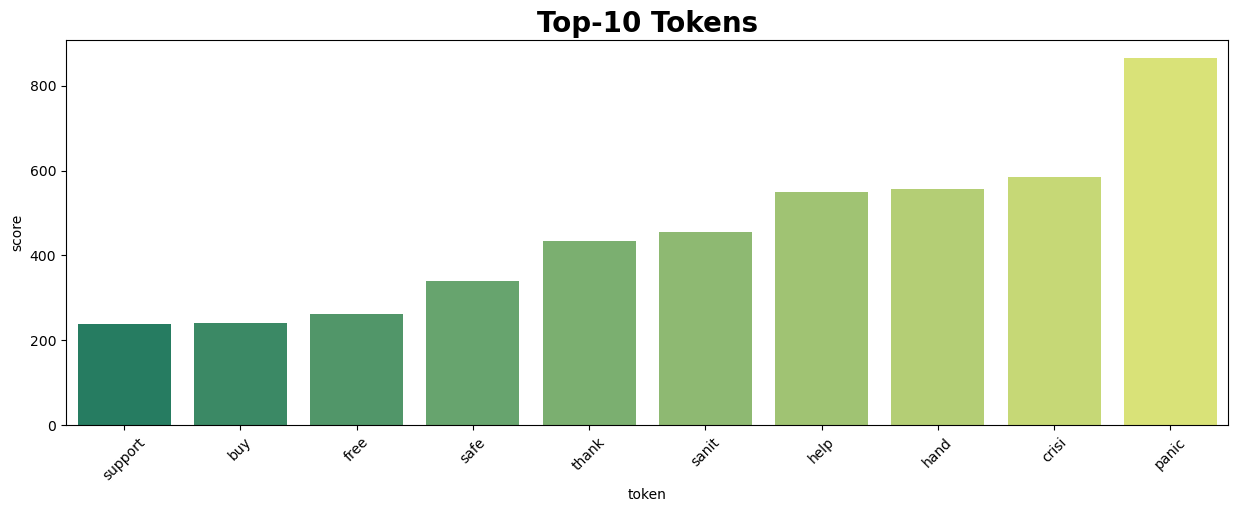

In [55]:
plt.figure(figsize=(15, 5))
sns.barplot(x="token", y="score", data=tokens_imp, palette="summer")
plt.title("Top-10 Tokens", size=20, weight="heavy") #заголовок
plt.xticks(rotation=45)
plt.show()

**Ответ:** приведенные выше токены имеют самые большие веса в модели после скалирования данных, что говорит о том, что именно они вносят существенный вклад в определение окраски твита. Полагаю, что слова "crisis" и "panic" скорее дают информацию о негативной окраске, а остальные - о позитивной.

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [56]:
#имя пользователя, заменено на целое число для анонимности
train["UserName"]

25621    35178
30135    40819
28899    39249
5989     11068
4367      9109
         ...  
20757    29120
32103    43291
30403    41159
21243    29702
2732      7104
Name: UserName, Length: 23410, dtype: int64

In [57]:
#отображающееся имя пользователя, заменено на целое число для анонимности
train["ScreenName"]

25621    80130
30135    85771
28899    84201
5989     56020
4367     54061
         ...  
20757    74072
32103    88243
30403    86111
21243    74654
2732     52056
Name: ScreenName, Length: 23410, dtype: int64

**Ответ:** насколько я поняла, в столбцах "UserName" и "ScreenName" содержатся числовые значения, которые не повторяются (можно провести аналогию с id). Такие признаки не улучшат модель, т.к. числа не несут смыслового значения, а являются просто кодами.

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [58]:
train["TweetAt"]

25621    06-04-2020
30135    10-04-2020
28899    09-04-2020
5989     19-03-2020
4367     18-03-2020
            ...    
20757    31-03-2020
32103    13-04-2020
30403    10-04-2020
21243    01-04-2020
2732     18-03-2020
Name: TweetAt, Length: 23410, dtype: object

Источник: https://pyhub.ru/python-advanced/lecture-11-76-133/

In [59]:
from datetime import datetime

train["TweetAt"] = train["TweetAt"].apply(lambda x: datetime.strptime(x, "%d-%m-%Y"))
train["TweetAt"]

25621   2020-04-06
30135   2020-04-10
28899   2020-04-09
5989    2020-03-19
4367    2020-03-18
           ...    
20757   2020-03-31
32103   2020-04-13
30403   2020-04-10
21243   2020-04-01
2732    2020-03-18
Name: TweetAt, Length: 23410, dtype: datetime64[ns]

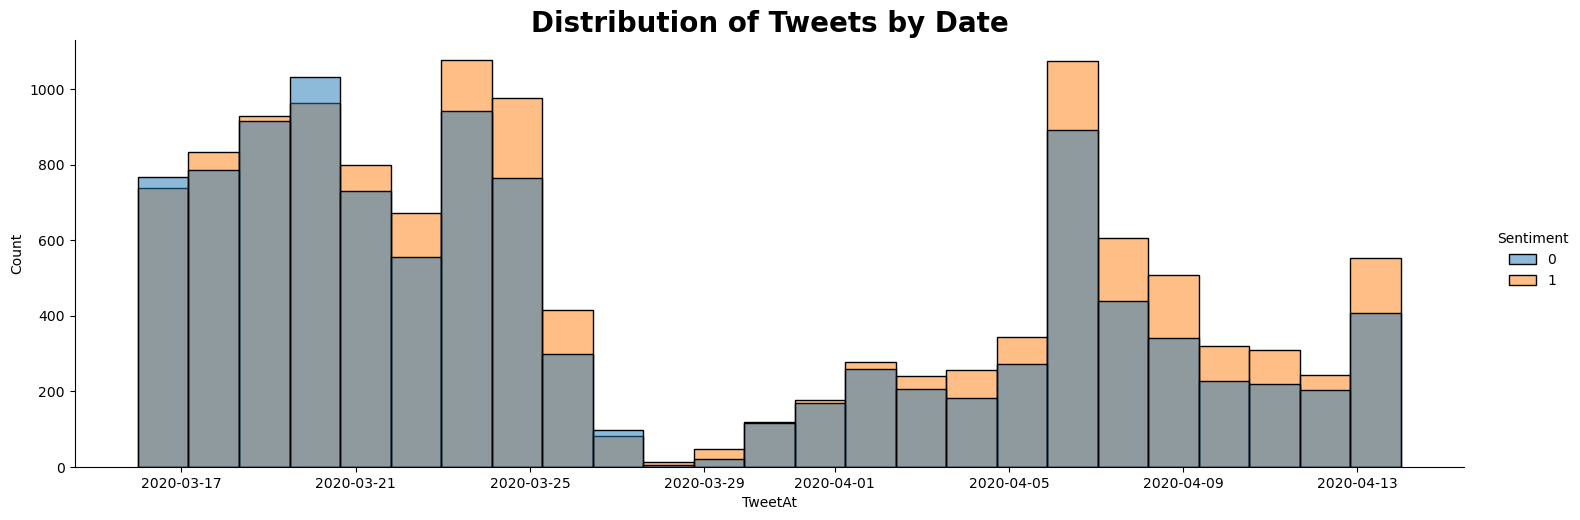

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(train, x="TweetAt", hue="Sentiment", aspect=3) #гистограмма
plt.title("Distribution of Tweets by Date", size=20, weight="heavy") #заголовок
plt.show()

**Ответ:** по графику видно, что изначально преобладали твиты с негативной окраской (примерно до 21 марта 2020 года), а затем преобладать стали позитивные, поэтому можно говорить о том, что признак "TweetAt" полезен.

In [61]:
train["TweetAt"].value_counts()

TweetAt
2020-03-20    1996
2020-03-19    1844
2020-03-25    1742
2020-03-18    1619
2020-03-21    1531
2020-03-22    1225
2020-03-23    1174
2020-03-17    1103
2020-04-08    1044
2020-04-07    1010
2020-04-06     956
2020-04-09     847
2020-03-24     843
2020-04-13     802
2020-03-26     713
2020-04-05     614
2020-04-10     545
2020-04-02     537
2020-04-11     528
2020-04-12     446
2020-04-03     446
2020-04-04     438
2020-03-16     402
2020-04-01     347
2020-03-31     188
2020-03-27     179
2020-04-14     159
2020-03-29      69
2020-03-30      47
2020-03-28      16
Name: count, dtype: int64

Источник: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html

In [62]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
train["TweetAt"] = enc.fit_transform(train[["TweetAt"]])
train["TweetAt"]

25621    21.0
30135    25.0
28899    24.0
5989      3.0
4367      2.0
         ... 
20757    15.0
32103    28.0
30403    25.0
21243    16.0
2732      2.0
Name: TweetAt, Length: 23410, dtype: float64

Источник: https://stackoverflow.com/questions/19710602/concatenate-sparse-matrices-in-python-using-scipy-numpy

In [63]:
from scipy.sparse import hstack

X_train_final1 = hstack((X_train_final, train[["TweetAt"]]))

In [64]:
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_train_final1, y_train)

test["TweetAt"] = test["TweetAt"].apply(lambda x: datetime.strptime(x, "%d-%m-%Y"))
test["TweetAt"] = enc.transform(test[["TweetAt"]])
X_test_final1 = hstack((X_test_final, test[["TweetAt"]]))

pred = lr.predict(X_test_final1)
print(accuracy_score(y_test, pred))

0.8449272473589795


Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [65]:
train["Location"].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [66]:
place = train.drop(train[train["Location"] == "Unknown"].index)
place = list(place["Location"])

In [67]:
location_freq = {}
for loc in place:
    location_freq[loc] = location_freq.get(loc, 0) + 1
dict_loc = pd.DataFrame.from_dict(location_freq, orient='index').reset_index() #преобразование словаря в датафрейм (ключи - строки), добавление колонки с порядковыми индексами
dict_loc.columns = ['Location', 'Frequency'] #даем названия колонкам
top10 = dict_loc.sort_values(by = "Frequency", ascending = False).head(10)

C:\Users\Соня\AppData\Local\Temp\ipykernel_18084\1589875587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Location", y="Frequency", data=top10, palette="summer")


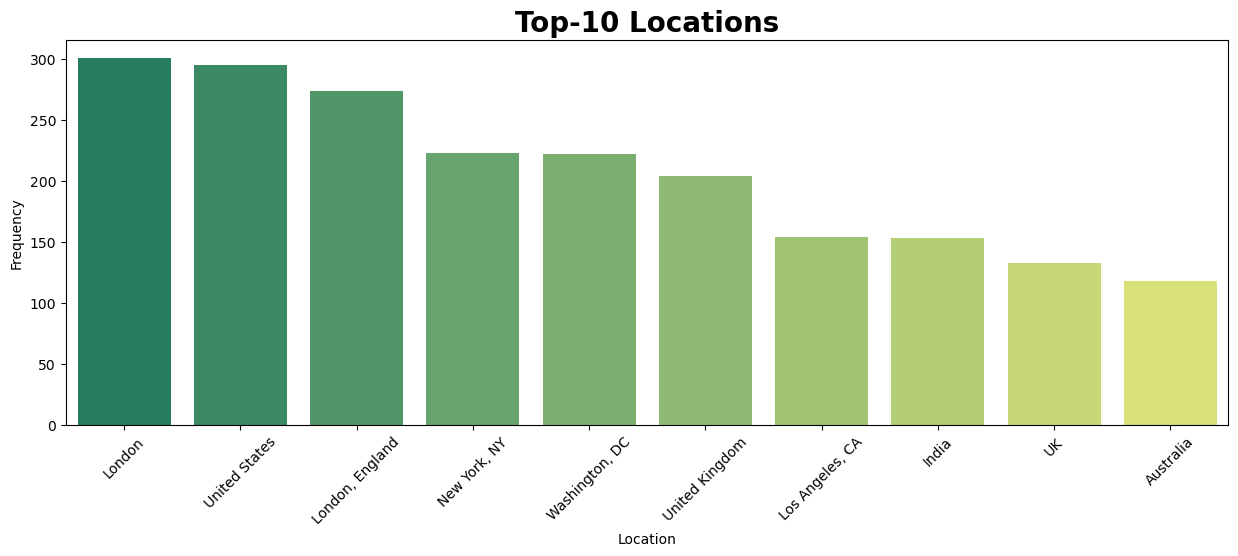

In [68]:
plt.figure(figsize=(15, 5))
sns.barplot(x="Location", y="Frequency", data=top10, palette="summer")
plt.title("Top-10 Locations", size=20, weight="heavy") #заголовок
plt.xticks(rotation=45)
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [69]:
train["WiderLocation"] = train["Location"].apply(lambda x: x.split(',')[-1].strip())
train["WiderLocation"]

25621        Unknown
30135          MA HQ
28899          India
5989              UK
4367             WNC
            ...     
20757        Unknown
32103             TX
30403    Delhi India
21243        Unknown
2732         Unknown
Name: WiderLocation, Length: 23410, dtype: object

In [70]:
train["WiderLocation"].nunique()

4631

C:\Users\Соня\AppData\Local\Temp\ipykernel_18084\2274002165.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Location", y="Frequency", data=top10_w, palette="summer")


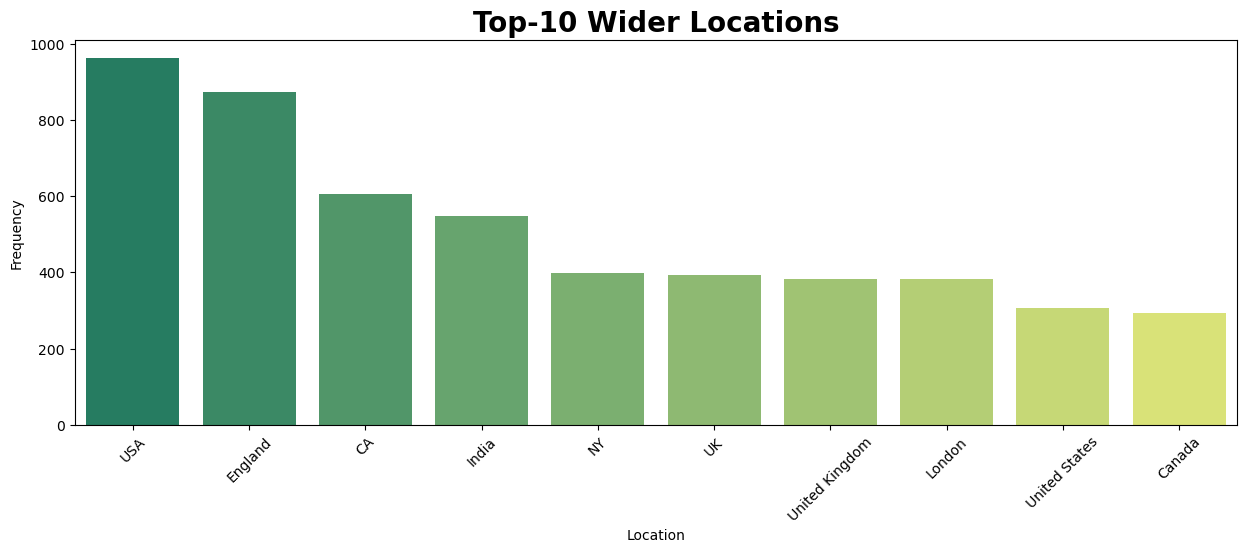

In [71]:
place_w = train.drop(train[train["WiderLocation"] == "Unknown"].index)
place_w = list(place_w["WiderLocation"])

location_freq_w = {}
for loc in place_w:
    location_freq_w[loc] = location_freq_w.get(loc, 0) + 1
dict_loc_w = pd.DataFrame.from_dict(location_freq_w, orient='index').reset_index() #преобразование словаря в датафрейм (ключи - строки), добавление колонки с порядковыми индексами
dict_loc_w.columns = ['Location', 'Frequency'] #даем названия колонкам
top10_w = dict_loc_w.sort_values(by = "Frequency", ascending = False).head(10)

plt.figure(figsize=(15, 5))
sns.barplot(x="Location", y="Frequency", data=top10_w, palette="summer")
plt.title("Top-10 Wider Locations", size=20, weight="heavy") #заголовок
plt.xticks(rotation=45)
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


Источник: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

In [72]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore", min_frequency=2)

ohe_values = enc.fit_transform(train[["WiderLocation"]])
ohe_df = pd.DataFrame(ohe_values, columns=enc.get_feature_names_out())

print(len(enc.get_feature_names_out()))

989


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [73]:
X_train_final2 = hstack((X_train_final1, ohe_df))

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final2, y_train)

test["WiderLocation"] = test["Location"].apply(lambda x: x.split(',')[-1].strip())
ohe_values_test = enc.transform(test[["WiderLocation"]])
ohe_df_test = pd.DataFrame(ohe_values_test, columns=enc.get_feature_names_out())

X_test_final2 = hstack((X_test_final1, ohe_df_test))

pred = lr.predict(X_test_final2)
print(accuracy_score(y_test, pred))

0.8448275862068966


**Ответ:** качество немного снизилось: было 0.84493, а стало 0.84483. В данном случае признак полезным не оказался.